In [1]:
%pip install opencv-python numpy pandas scikit-learn matplotlib joblib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

from skimage.feature import hog, local_binary_pattern
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, precision_score,
                             recall_score, f1_score)

print('All libraries imported successfully!')

All libraries imported successfully!


In [3]:
from pathlib import Path

# Project root
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "dataset"
MODEL_DIR = PROJECT_ROOT / "models" / "meander"

# Original HandPD dataset
PD_PATH_ORIGINAL = DATA_DIR / "raw" / "meander" / "parkinson" / "MeanderPatients"
HEALTHY_PATH_ORIGINAL = DATA_DIR / "raw" / "meander" / "healthy" / "MeanderControl"

# Camera-style dataset variations
PD_PATH_CAMERA = DATA_DIR / "raw_camera" / "meander_camera" / "parkinson" / "MeanderPatients"
HEALTHY_PATH_CAMERA = DATA_DIR / "raw_camera" / "meander_camera" / "healthy" / "MeanderControl"

# Real captured images
PD_PATH_REAL = DATA_DIR / "real" / "meander" / "parkinson"
HEALTHY_PATH_REAL = DATA_DIR / "real" / "meander" / "healthy"

# Combine datasets
PD_PATH = [PD_PATH_ORIGINAL, PD_PATH_CAMERA, PD_PATH_REAL]
HEALTHY_PATH = [HEALTHY_PATH_ORIGINAL, HEALTHY_PATH_CAMERA, HEALTHY_PATH_REAL]

# Save final combined model
MODEL_SAVE_PATH = MODEL_DIR / "meander_model_combined.pkl"

# Image size — same as spiral model
IMG_SIZE = (128, 128)

# Create model directory if it doesn't exist
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Paths configured!")
print(f"PD path          : {PD_PATH}")
print(f"Healthy path     : {HEALTHY_PATH}")
print(f"Model save path  : {MODEL_SAVE_PATH}")

Paths configured!
PD path          : [WindowsPath('c:/Users/User/OneDrive/Documents/JOBS/PORTFOLIO/PD-HAND/dataset/raw/meander/parkinson/MeanderPatients'), WindowsPath('c:/Users/User/OneDrive/Documents/JOBS/PORTFOLIO/PD-HAND/dataset/raw_camera/meander_camera/parkinson/MeanderPatients'), WindowsPath('c:/Users/User/OneDrive/Documents/JOBS/PORTFOLIO/PD-HAND/dataset/real/meander/parkinson')]
Healthy path     : [WindowsPath('c:/Users/User/OneDrive/Documents/JOBS/PORTFOLIO/PD-HAND/dataset/raw/meander/healthy/MeanderControl'), WindowsPath('c:/Users/User/OneDrive/Documents/JOBS/PORTFOLIO/PD-HAND/dataset/raw_camera/meander_camera/healthy/MeanderControl'), WindowsPath('c:/Users/User/OneDrive/Documents/JOBS/PORTFOLIO/PD-HAND/dataset/real/meander/healthy')]
Model save path  : c:\Users\User\OneDrive\Documents\JOBS\PORTFOLIO\PD-HAND\models\meander\meander_model_combined.pkl


In [5]:
# Load from BOTH original and camera folders
pd_files = []
for folder in PD_PATH:
    pd_files.extend([f for f in os.listdir(folder)
                     if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

healthy_files = []
for folder in HEALTHY_PATH:
    healthy_files.extend([f for f in os.listdir(folder)
                          if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

print(f'PD meander images      : {len(pd_files)} (combined)')
print(f'Healthy meander images : {len(healthy_files)} (combined)')
print(f'Total                  : {len(pd_files) + len(healthy_files)} (2x more!)')

PD meander images      : 645 (combined)
Healthy meander images : 189 (combined)
Total                  : 834 (2x more!)


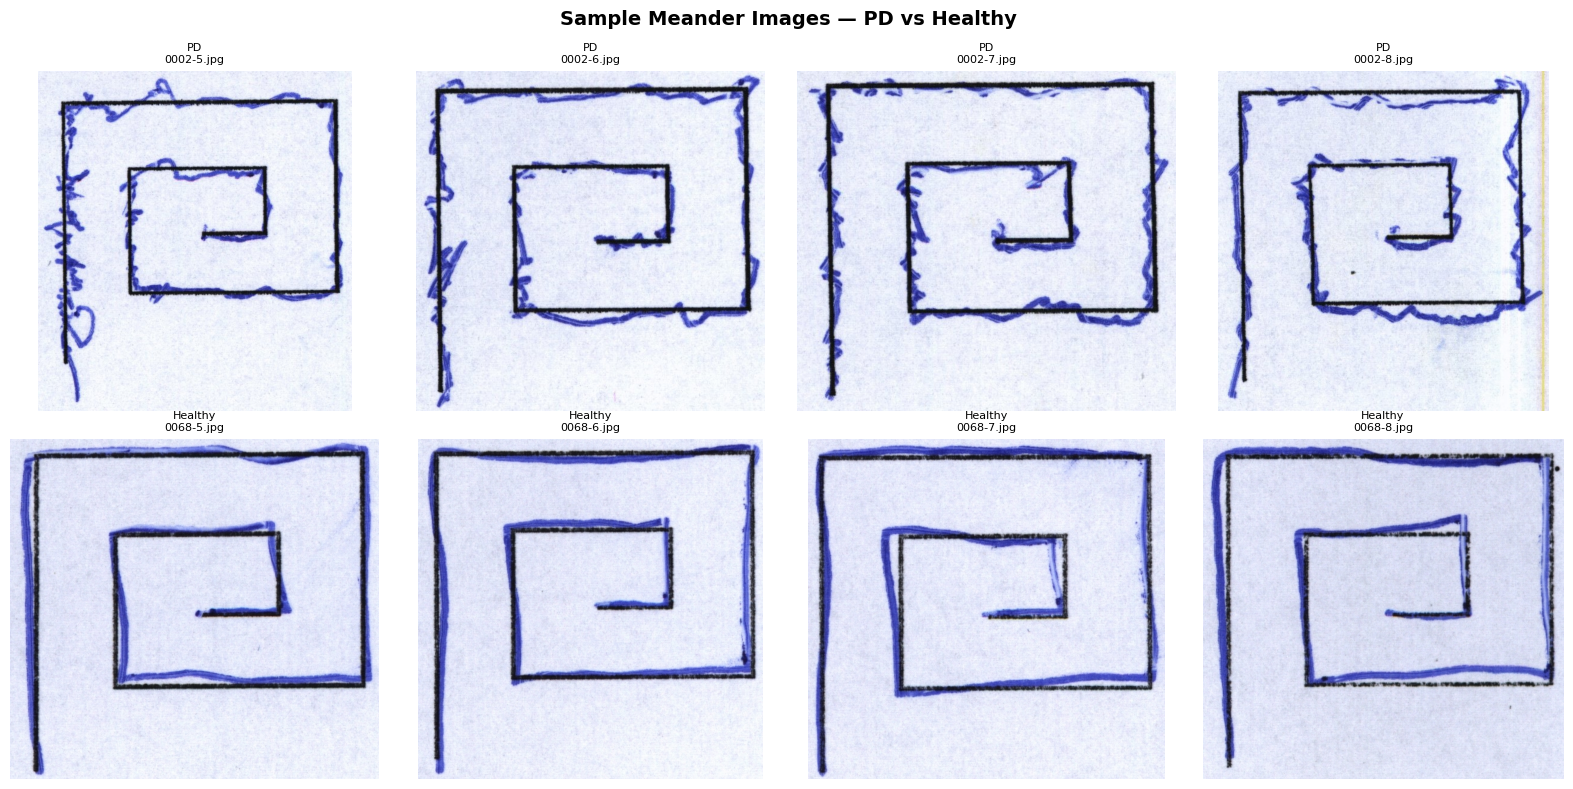

Check images above — meander patterns should show tremor differences!
(Showing samples from original dataset folder)


In [6]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Sample Meander Images — PD vs Healthy',
             fontsize=14, fontweight='bold')

label_data = [
    ('PD', PD_PATH),
    ('Healthy', HEALTHY_PATH)
]

for i, (label, folders) in enumerate(label_data):
    # Get files from FIRST folder (original) for preview
    first_folder = folders[0]  # ← Extract string from list
    files = [f for f in os.listdir(first_folder)
             if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    for j in range(4):
        if j < len(files):
            img = cv2.imread(os.path.join(first_folder, files[j]))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[i][j].imshow(img)
            axes[i][j].set_title(f'{label}\n{files[j]}', fontsize=8)
        axes[i][j].axis('off')

plt.tight_layout()
plt.show()
print('Check images above — meander patterns should show tremor differences!')
print(f'(Showing samples from original dataset folder)')

In [7]:
def preprocess_image(image_path):
    """
    Same preprocessing pipeline as spiral model.
    Resize → Grayscale → GaussianBlur → Otsu Threshold
    """
    image = cv2.imread(image_path)

    if image is None:
        raise ValueError(f'Unable to read image: {image_path}')

    resized = cv2.resize(image, IMG_SIZE)
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    gray = clahe.apply(gray)

    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    _, thresh = cv2.threshold(
        blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    return gray, thresh


def extract_features(thresh_img):
    """
    Extract same 12 features as spiral model.
    Keeps both models consistent and comparable.
    """
    features = {}

    # Basic ink features
    ink_pixels   = np.sum(thresh_img > 0)
    total_pixels = thresh_img.size
    ink_ratio    = ink_pixels / total_pixels

    features['ink_pixels'] = int(ink_pixels)
    features['ink_ratio']  = float(ink_ratio)

    # Contour features
    contours, _ = cv2.findContours(
        thresh_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    features['num_contours'] = len(contours)

    if contours:
        largest           = max(contours, key=cv2.contourArea)
        contour_area      = cv2.contourArea(largest)
        contour_perimeter = cv2.arcLength(largest, True)
        x, y, w, h        = cv2.boundingRect(largest)
        aspect_ratio      = w / h if h != 0 else 0

        M = cv2.moments(largest)
        if M['m00'] != 0:
            centroid_x = M['m10'] / M['m00']
            centroid_y = M['m01'] / M['m00']
        else:
            centroid_x, centroid_y = 0, 0

        rect_area = w * h
        extent    = contour_area / rect_area if rect_area != 0 else 0
        hull      = cv2.convexHull(largest)
        hull_area = cv2.contourArea(hull)
        solidity  = contour_area / hull_area if hull_area != 0 else 0
    else:
        contour_area = contour_perimeter = 0
        w = h = 0
        aspect_ratio = centroid_x = centroid_y = extent = solidity = 0

    features['contour_area']        = float(contour_area)
    features['contour_perimeter']   = float(contour_perimeter)
    features['bounding_box_width']  = int(w)
    features['bounding_box_height'] = int(h)
    features['aspect_ratio']        = float(aspect_ratio)
    features['centroid_x']          = float(centroid_x)
    features['centroid_y']          = float(centroid_y)
    features['extent'] = float(extent)
    features['solidity'] = float(solidity)

    # HOG features
    hog_features = hog(
        thresh_img,
        orientations=8,
        pixels_per_cell=(16, 16),
        cells_per_block=(1, 1),
        visualize=False
    )

    for i, val in enumerate(hog_features):
        features[f'hog_{i}'] = float(val)

    # LBP features
    lbp = local_binary_pattern(
        thresh_img,
        P=8,
        R=1,
        method='uniform'
    )

    lbp_hist, _ = np.histogram(
        lbp.ravel(),
        bins=10,
        range=(0, 10),
        density=True
    )

    for i, val in enumerate(lbp_hist):
        features[f'lbp_{i}'] = float(val)

    # Hu Moments
    moments = cv2.moments(thresh_img)

    hu_moments = cv2.HuMoments(
        moments
    ).flatten()

    for i, val in enumerate(hu_moments):
        features[f'hu_{i}'] = float(
            np.sign(val) * np.log1p(abs(val))
        )

    return features

In [8]:
def simulate_plain_paper(thresh_img):
    """Generate plain-paper style variants from a thresholded dataset image."""
    variants = []
    _, dark_only = cv2.threshold(thresh_img, 127, 255, cv2.THRESH_BINARY)
    variants.append(dark_only)
    
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2))
    dilated = cv2.dilate(dark_only, kernel, iterations=1)
    variants.append(dilated)
    
    eroded = cv2.erode(dark_only, kernel, iterations=1)
    variants.append(eroded)
    
    return variants

all_features  = []
all_labels    = []
all_filenames = []
failed        = []

# Loop through labels (PD vs Healthy)
for label_value, folders, label_name in [
    (1, PD_PATH, 'PD'),
    (0, HEALTHY_PATH, 'Healthy')
]:
    # Loop through MULTIPLE folders (original + camera)
    for folder in folders:
        # Get list of image files from this folder
        files = [f for f in os.listdir(folder)
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        print(f'Extracting features from {len(files)} {label_name} images...')
        
        # Process each image file
        for fname in files:
            fpath = os.path.join(folder, fname)
            try:
                _, thresh = preprocess_image(fpath)
                
                # Original image features
                features = extract_features(thresh)
                all_features.append(features)
                all_labels.append(label_value)
                all_filenames.append(fname)
                
                # Augmented plain-paper variants
                for aug_thresh in simulate_plain_paper(thresh):
                    aug_features = extract_features(aug_thresh)
                    all_features.append(aug_features)
                    all_labels.append(label_value)
                    all_filenames.append(fname + '_aug')
            
            except Exception as e:
                failed.append(f'{fname}: {str(e)}')

print(f'\nFeature extraction complete!')
print(f'Total samples    : {len(all_features)}')
print(f'PD samples       : {sum(all_labels)}')
print(f'Healthy samples  : {len(all_labels) - sum(all_labels)}')
print(f'Failed           : {len(failed)}')
if failed:
    print('Failed files:')
    for f in failed[:5]:
        print(f'  {f}')

Extracting features from 296 PD images...
Extracting features from 296 PD images...
Extracting features from 53 PD images...
Extracting features from 72 Healthy images...
Extracting features from 72 Healthy images...
Extracting features from 45 Healthy images...

Feature extraction complete!
Total samples    : 3336
PD samples       : 2580
Healthy samples  : 756
Failed           : 0


In [9]:
df = pd.DataFrame(all_features)
df['label']    = all_labels
df['filename'] = all_filenames

FEATURE_ORDER = [
    col for col in df.columns
    if col not in ['label', 'filename']
]

print(f'Preprocessing and feature extraction functions defined!')
print(f'Number of features : {len(FEATURE_ORDER)}')
print(f'Features           : {FEATURE_ORDER}')

# ===== DATASET BALANCING (NEW!) =====
from sklearn.utils import resample

df_temp = df.copy()
pd_count = len(df_temp[df_temp['label'] == 1])
healthy_count = len(df_temp[df_temp['label'] == 0])

print(f"\n🔄 BALANCING DATASET:")
print(f"Before balancing: PD={pd_count}, Healthy={healthy_count}, Ratio={pd_count/healthy_count:.2f}x")

if pd_count > healthy_count:
    df_pd = df_temp[df_temp['label'] == 1]
    df_healthy = df_temp[df_temp['label'] == 0]
    df_pd_balanced = resample(df_pd, n_samples=healthy_count, random_state=42, replace=False)
    df = pd.concat([df_pd_balanced, df_healthy], ignore_index=True)
    df = df.sample(frac=1, random_state=42)  # Shuffle
    
    balanced_pd = len(df[df['label'] == 1])
    balanced_healthy = len(df[df['label'] == 0])
    print(f"After balancing:  PD={balanced_pd}, Healthy={balanced_healthy}, Ratio=1.00x ✅")
    print(f"Total samples: {len(df)}")
else:
    print(f"Healthy > PD, no balancing needed")

print('Dataframe shape:', df.shape)
print('\nLabel distribution:')
print(df['label'].value_counts())
print('\nFirst 5 rows:')
print(df.head())
print('\nBasic statistics:')
print(df.describe())

Preprocessing and feature extraction functions defined!
Number of features : 541
Features           : ['ink_pixels', 'ink_ratio', 'num_contours', 'contour_area', 'contour_perimeter', 'bounding_box_width', 'bounding_box_height', 'aspect_ratio', 'centroid_x', 'centroid_y', 'extent', 'solidity', 'hog_0', 'hog_1', 'hog_2', 'hog_3', 'hog_4', 'hog_5', 'hog_6', 'hog_7', 'hog_8', 'hog_9', 'hog_10', 'hog_11', 'hog_12', 'hog_13', 'hog_14', 'hog_15', 'hog_16', 'hog_17', 'hog_18', 'hog_19', 'hog_20', 'hog_21', 'hog_22', 'hog_23', 'hog_24', 'hog_25', 'hog_26', 'hog_27', 'hog_28', 'hog_29', 'hog_30', 'hog_31', 'hog_32', 'hog_33', 'hog_34', 'hog_35', 'hog_36', 'hog_37', 'hog_38', 'hog_39', 'hog_40', 'hog_41', 'hog_42', 'hog_43', 'hog_44', 'hog_45', 'hog_46', 'hog_47', 'hog_48', 'hog_49', 'hog_50', 'hog_51', 'hog_52', 'hog_53', 'hog_54', 'hog_55', 'hog_56', 'hog_57', 'hog_58', 'hog_59', 'hog_60', 'hog_61', 'hog_62', 'hog_63', 'hog_64', 'hog_65', 'hog_66', 'hog_67', 'hog_68', 'hog_69', 'hog_70', 'hog_7

In [10]:
print("Number of features:", len(FEATURE_ORDER))
print(FEATURE_ORDER[:20])

Number of features: 541
['ink_pixels', 'ink_ratio', 'num_contours', 'contour_area', 'contour_perimeter', 'bounding_box_width', 'bounding_box_height', 'aspect_ratio', 'centroid_x', 'centroid_y', 'extent', 'solidity', 'hog_0', 'hog_1', 'hog_2', 'hog_3', 'hog_4', 'hog_5', 'hog_6', 'hog_7']


In [11]:
X = df[FEATURE_ORDER].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Training samples : {len(X_train)}')
print(f'Testing samples  : {len(X_test)}')
print(f'Train PD         : {sum(y_train)}')
print(f'Train Healthy    : {len(y_train) - sum(y_train)}')
print(f'Test PD          : {sum(y_test)}')
print(f'Test Healthy     : {len(y_test) - sum(y_test)}')

Training samples : 1209
Testing samples  : 303
Train PD         : 605
Train Healthy    : 604
Test PD          : 151
Test Healthy     : 152


In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

classifiers = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            max_iter=1000,
            random_state=42,
            class_weight='balanced'
        ))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        max_features='sqrt',
        min_samples_leaf=1,
        min_samples_split=2,
        random_state=42,
        class_weight='balanced'
    ),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(
            probability=True,
            random_state=42,
            class_weight='balanced'
        ))
    ])
}

In [13]:
results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, clf in classifiers.items():
    print(f'Training {name}...')
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    cm   = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    cv_scores = cross_val_score(clf, X, y, cv=cv, scoring='f1')

    results.append({
        'Model'      : name,
        'Accuracy'   : round(acc, 4),
        'Precision'  : round(prec, 4),
        'Recall'     : round(rec, 4),
        'F1-score'   : round(f1, 4),
        'CV F1 Mean' : round(cv_scores.mean(), 4),
        'CV F1 Std'  : round(cv_scores.std(), 4),
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp
    })

    print(f'  Accuracy   : {acc*100:.2f}%')
    print(f'  F1 Score   : {f1:.4f}')
    print(f'  CV F1 Mean : {cv_scores.mean():.4f}')
    print()

results_df = pd.DataFrame(results)
print('Full Comparison Table:')
display(results_df[['Model', 'Accuracy', 'Precision',
                     'Recall', 'F1-score',
                     'CV F1 Mean', 'CV F1 Std',
                     'TN', 'FP', 'FN', 'TP']])

Training Logistic Regression...
  Accuracy   : 90.76%
  F1 Score   : 0.9041
  CV F1 Mean : 0.8928

Training Random Forest...
  Accuracy   : 97.36%
  F1 Score   : 0.9730
  CV F1 Mean : 0.9633

Training SVM...
  Accuracy   : 96.04%
  F1 Score   : 0.9595
  CV F1 Mean : 0.9455

Full Comparison Table:


,Model,Accuracy,Precision,Recall,F1-score,CV F1 Mean,CV F1 Std,TN,FP,FN,TP
0,Logistic Regression,0.9076,0.9362,0.8742,0.9041,0.8928,0.0158,143,9,19,132
1,Random Forest,0.9736,0.9931,0.9536,0.9730,0.9633,0.0113,151,1,7,144
2,SVM,0.9604,0.9793,0.9404,0.9595,0.9455,0.0146,149,3,9,142


In [14]:
best_idx   = results_df['CV F1 Mean'].idxmax()
best_model = results_df.loc[best_idx, 'Model']

print('=' * 50)
print('MODEL COMPARISON SUMMARY')
print('=' * 50)
display(results_df[['Model', 'Accuracy', 'Precision',
                     'Recall', 'F1-score',
                     'CV F1 Mean', 'CV F1 Std',
                     'TN', 'FP', 'FN', 'TP']])
print()
print(f'Best model        : {best_model}')
print(f'Best CV F1 Mean   : {results_df.loc[best_idx, "CV F1 Mean"]}')
print(f'Best Accuracy     : {results_df.loc[best_idx, "Accuracy"] * 100:.2f}%')

MODEL COMPARISON SUMMARY


,Model,Accuracy,Precision,Recall,F1-score,CV F1 Mean,CV F1 Std,TN,FP,FN,TP
0,Logistic Regression,0.9076,0.9362,0.8742,0.9041,0.8928,0.0158,143,9,19,132
1,Random Forest,0.9736,0.9931,0.9536,0.9730,0.9633,0.0113,151,1,7,144
2,SVM,0.9604,0.9793,0.9404,0.9595,0.9455,0.0146,149,3,9,142



Best model        : Random Forest
Best CV F1 Mean   : 0.9633
Best Accuracy     : 97.36%


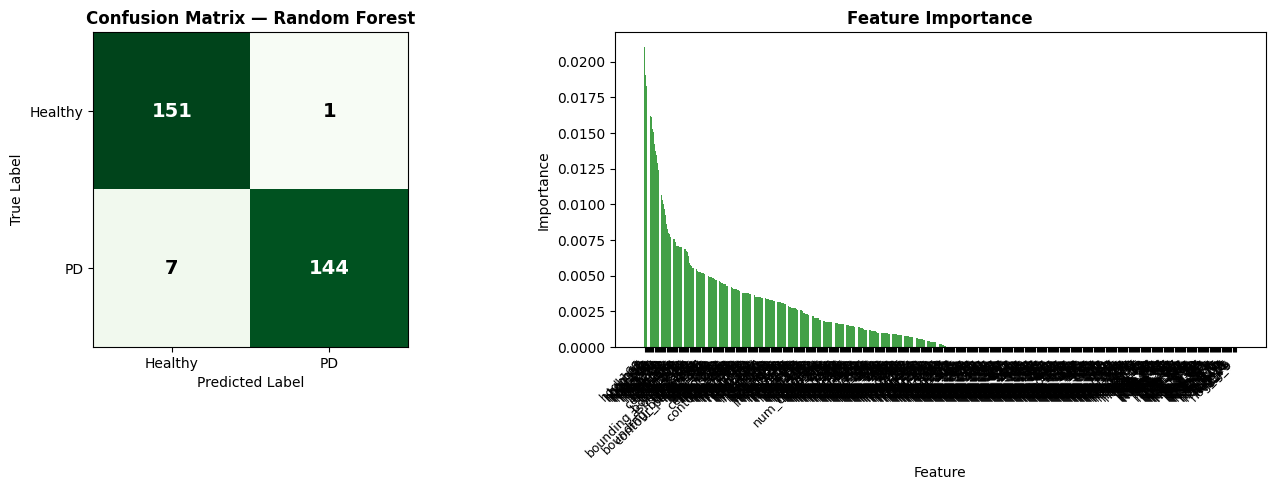

Evaluation plot saved as meander_model_evaluation.png


In [15]:
best_clf   = classifiers[best_model]
y_pred_best = best_clf.predict(X_test)
cm          = confusion_matrix(y_test, y_pred_best)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
im = axes[0].imshow(cm, interpolation='nearest', cmap=plt.cm.Greens)
axes[0].set_title(f'Confusion Matrix — {best_model}',
                  fontweight='bold', fontsize=12)
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Healthy', 'PD'])
axes[0].set_yticklabels(['Healthy', 'PD'])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[0].text(j, i, str(cm[i, j]),
                     ha='center', va='center',
                     color='white' if cm[i,j] > cm.max()/2 else 'black',
                     fontsize=14, fontweight='bold')

# Feature importance (only for Random Forest)
if best_model == 'Random Forest':
    importances = best_clf.feature_importances_
    indices     = np.argsort(importances)[::-1]
    axes[1].bar(range(len(FEATURE_ORDER)),
                importances[indices], color='#43A047')
    axes[1].set_title('Feature Importance', fontweight='bold', fontsize=12)
    axes[1].set_xlabel('Feature')
    axes[1].set_ylabel('Importance')
    axes[1].set_xticks(range(len(FEATURE_ORDER)))
    axes[1].set_xticklabels(
        [FEATURE_ORDER[i] for i in indices],
        rotation=45, ha='right', fontsize=9
    )
else:
    axes[1].text(0.5, 0.5, f'Feature importance\nnot available for {best_model}',
                 ha='center', va='center', fontsize=12,
                 transform=axes[1].transAxes)
    axes[1].axis('off')

plt.tight_layout()
plt.savefig('meander_model_evaluation.png', dpi=100, bbox_inches='tight')
plt.show()
print('Evaluation plot saved as meander_model_evaluation.png')

In [16]:
import copy

# Retrain best model on FULL dataset before saving
final_model = copy.deepcopy(classifiers[best_model])
final_model.fit(X, y)

joblib.dump(final_model, MODEL_SAVE_PATH)

best_acc = results_df.loc[best_idx, 'Accuracy']
best_cv  = results_df.loc[best_idx, 'CV F1 Mean']

print('=' * 50)
print('FINAL MODEL SAVED SUCCESSFULLY!')
print('=' * 50)
print(f'Best model    : {best_model}')
print(f'Saved to      : {MODEL_SAVE_PATH}')
print(f'Test Accuracy : {best_acc * 100:.2f}%')
print(f'CV F1 Mean    : {best_cv:.4f}')
print(f'Trained on    : {len(X)} total samples (full dataset)')
print(f'\nFeature order (must match predict.py):')
for i, f in enumerate(FEATURE_ORDER):
    print(f'  {i+1}. {f}')

FINAL MODEL SAVED SUCCESSFULLY!
Best model    : Random Forest
Saved to      : c:\Users\User\OneDrive\Documents\JOBS\PORTFOLIO\PD-HAND\models\meander\meander_model_combined.pkl
Test Accuracy : 97.36%
CV F1 Mean    : 0.9633
Trained on    : 1512 total samples (full dataset)

Feature order (must match predict.py):
  1. ink_pixels
  2. ink_ratio
  3. num_contours
  4. contour_area
  5. contour_perimeter
  6. bounding_box_width
  7. bounding_box_height
  8. aspect_ratio
  9. centroid_x
  10. centroid_y
  11. extent
  12. solidity
  13. hog_0
  14. hog_1
  15. hog_2
  16. hog_3
  17. hog_4
  18. hog_5
  19. hog_6
  20. hog_7
  21. hog_8
  22. hog_9
  23. hog_10
  24. hog_11
  25. hog_12
  26. hog_13
  27. hog_14
  28. hog_15
  29. hog_16
  30. hog_17
  31. hog_18
  32. hog_19
  33. hog_20
  34. hog_21
  35. hog_22
  36. hog_23
  37. hog_24
  38. hog_25
  39. hog_26
  40. hog_27
  41. hog_28
  42. hog_29
  43. hog_30
  44. hog_31
  45. hog_32
  46. hog_33
  47. hog_34
  48. hog_35
  49. hog_36